
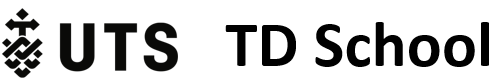



# **36103 Statistical Thinking for Data Science**



 ## **Tutorial 2 : Linear Regression and Logistic Regression**


In this tutorial, we will explore practical applications of linear regression and logistic regression methods.

We will be using the same property house data that we explored during last week's EDA. The next step in our analysis involves trying out different models.

The objective is to predict the sale price (response variable).
***

## 1. Import Data and Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Settings
sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
gGrive_data_path = '/MyDrive/UTS/data/Tu1HousingPriceData-5.csv'

In [27]:
# Reading in data
data = pd.read_csv('/content/drive' + gGrive_data_path)
data.head()

,SalePrice,YearSold,LotFrontage,LotSize,HouseStyle,OverallQual,OverallCond,YearBuilt,ExterQual,ExterCond,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,FullBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,SaleType,SaleCondition
0,189920,2310,74.0,13840,2Story,5,5,1997,TA,TA,928.0,928,701,1629,2,3,1,TA,6,Attchd,1997.0,Fin,2.0,482.0,WD,Normal
1,195510,2010,78.0,9987,2Story,6,6,1998,TA,TA,926.0,926,678,1604,2,3,1,Gd,7,Attchd,1998.0,Fin,2.0,470.0,WD,Normal
2,213510,2010,41.0,4920,1Story,8,5,2001,Gd,TA,1338.0,1338,0,1338,2,2,1,Gd,6,Attchd,2001.0,Fin,2.0,582.0,WD,Normal
3,191500,2010,43.0,5005,1Story,8,5,1992,Gd,TA,1280.0,1280,0,1280,2,2,1,Gd,5,Attchd,1992.0,RFn,2.0,506.0,WD,Normal
4,234500,2010,39.0,5389,1Story,8,5,1995,Gd,TA,1595.0,1616,0,1616,2,2,1,Gd,5,Attchd,1995.0,RFn,2.0,608.0,WD,Normal


## 2. Data Cleaning
*(Repeated Steps From First Tutorial)*


Replace error values in the dataset
- The dataset contains some error values that need to be corrected. For instance, the `'YearSold'` variable has a value of 2310, which is likely a typo and should be replaced with 2010.
- Additionally, data contain duplicate rows that need to be removed.
- Moreover, we will remove rows with missing values in the `'TotalBsmtSF'`, `'GarageCars'`, and `'GarageArea'` variables.
- `'LotFrontage'` has missing values, which we will handle by replacing them with the median value based on the `'HouseStyle'` variable.
- Finally, we will replace missing values in `'GarageType'` with `'No Garage'`, `'GarageFinish'` with `'None'`, and `'GarageYrBlt'` with the value from `'YearBuilt'`.

Details of the cleaning process are explained in Tutiorial 1 notebook.

In [28]:
# Replace the maximum value of YearSold with 2010
data['YearSold'] = data['YearSold'].replace(2310, 2010)

In [29]:
# Remove duplicates from the dataset
data = data.drop_duplicates()

In [30]:
# Remove rows with missing values in TotalBsmtSF, GarageCars and GarageArea
data = data.dropna(subset=['TotalBsmtSF', 'GarageCars', 'GarageArea'])

In [31]:
# Replace missing values in LotFrontage with the median value based on the HouseStyle

# Create a copy of the original LotFrontage, so we can compare before and after imputation
data['LotFrontage_imputed_basic'] = data['LotFrontage']

# Loop through each unique HouseStyle and fill missing LotFrontage with the median
for style in data['HouseStyle'].unique():
    median_value = data[data['HouseStyle'] == style]['LotFrontage'].median()
    mask = (data['HouseStyle'] == style) & (data['LotFrontage_imputed_basic'].isnull())
    data.loc[mask, 'LotFrontage_imputed_basic'] = median_value

# Count any remaining missing values
data['LotFrontage_imputed_basic'].isnull().sum()

# Remove the original LotFrontage column
data = data.drop(columns=['LotFrontage'])  # Drop the original LotFrontage column

# Rename the imputed column to LotFrontage
data = data.rename(columns={'LotFrontage_imputed_basic': 'LotFrontage'})


In [32]:
# Replace missing GarageType with 'No Garage'
data['GarageType'] = data['GarageType'].fillna('No Garage')

# Replace missing GarageFinish with 'None'
data['GarageFinish'] = data['GarageFinish'].fillna('None')

# Replace missing GarageYrBlt with YearBuilt
data['GarageYrBlt'] = data['GarageYrBlt'].fillna(data['YearBuilt'])
# Check for missing values again
missing_values = data.isnull().sum()  # Recalculate missing values
print(f"Missing values after handling: \n{missing_values}")

Missing values after handling: 
SalePrice        0
YearSold         0
LotSize          0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
ExterQual        0
ExterCond        0
TotalBsmtSF      0
1stFlrSF         0
2ndFlrSF         0
GrLivArea        0
FullBath         0
BedroomAbvGr     0
KitchenAbvGr     0
KitchenQual      0
TotRmsAbvGrd     0
GarageType       0
GarageYrBlt      0
GarageFinish     0
GarageCars       0
GarageArea       0
SaleType         0
SaleCondition    0
LotFrontage      0
dtype: int64


In [33]:
# Log-transform the SalePrice variable
data['LSalePrice'] = np.log(data['SalePrice'])

## 3. Feature Selection

### Data Splitting

Data splitting involves dividing the dataset into two subsets: a training set and a test set. The training set is used to build and analyze the model, while the test set is reserved for evaluating its performance on unseen data. This step is done before any analysis or modeling to prevent data leakage and ensure the model generalizes well to new data.

In [34]:
# Split the data into training and validation sets
index_train, index_valid = train_test_split(data.index, train_size=0.8, random_state=21)

# Generate training and validation sets
train = data.loc[index_train, :].copy()
valid = data.loc[index_valid, :].copy()

### 3.1 Continuous Variables

Before we proceed with the analysis, we need to select the features that will be used in our model. Feature selection is a crucial step in the data preprocessing phase, as it helps us identify the most relevant variables for our analysis.

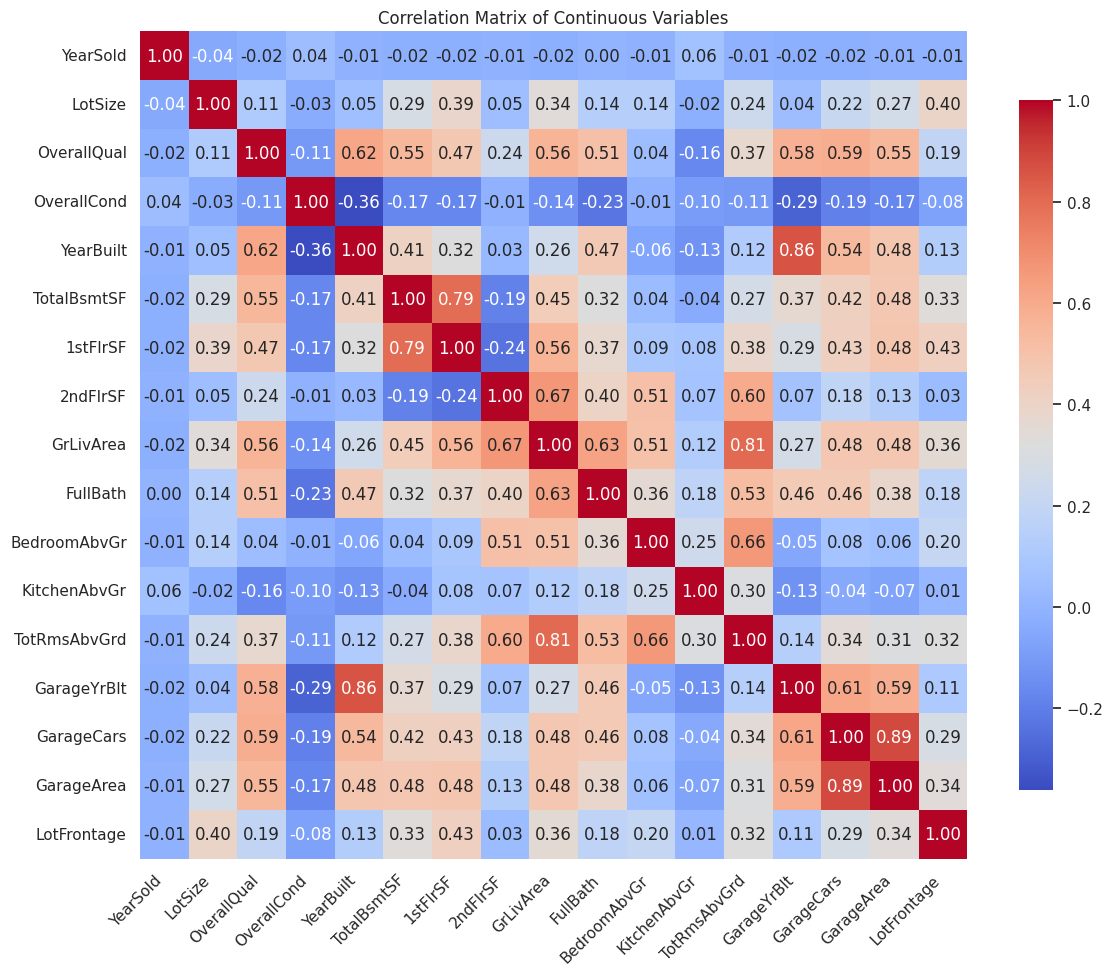

In [35]:
# Numerical Variables Excluding Sale Price and Log Sale Price
numerical_vars = train.select_dtypes(include=['number']).columns.tolist()

# Exclude SalePrice and Log Sale Price
numerical_vars = [var for var in numerical_vars if var not in ['SalePrice', 'LSalePrice']]

# Compute the correlation matrix for continuous variables
correlation_matrix = train[numerical_vars].corr()
# Set up the matplotlib figure
plt.figure(figsize=(12, 10))
# Create a heatmap of the correlation matrix
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
# Set title and labels
plt.title('Correlation Matrix of Continuous Variables')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

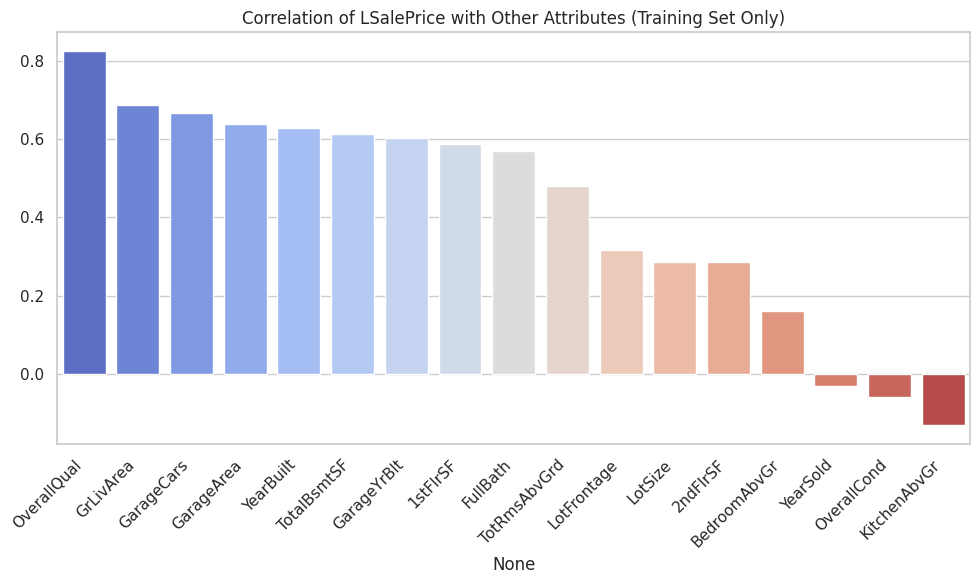

In [36]:
# Compute the correlation matrix on the training set only to prevent leakage
correlation_matrix_train = train.select_dtypes(include=['number']).corr()

# Get the correlation of 'LSalePrice' with other attributes
lsaleprice_corr = correlation_matrix_train['LSalePrice'].drop(['SalePrice', 'LSalePrice'])

# Sort the correlations from high to low
lsaleprice_corr_sorted = lsaleprice_corr.sort_values(ascending=False)

# Visualize the correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=lsaleprice_corr_sorted.index, y=lsaleprice_corr_sorted.values, palette='coolwarm', hue=lsaleprice_corr_sorted.index, legend=False)
plt.title('Correlation of LSalePrice with Other Attributes (Training Set Only)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [37]:
# Selecting the top continuous variables based on correlation with LSalePrice
n = 3 # Number of top variables to select
top_continuous_vars = lsaleprice_corr_sorted.index[:n].tolist()
print(f"Top {n} continuous variables with highest correlation with LSalePrice: {top_continuous_vars}")


Top 3 continuous variables with highest correlation with LSalePrice: ['OverallQual', 'GrLivArea', 'GarageCars']


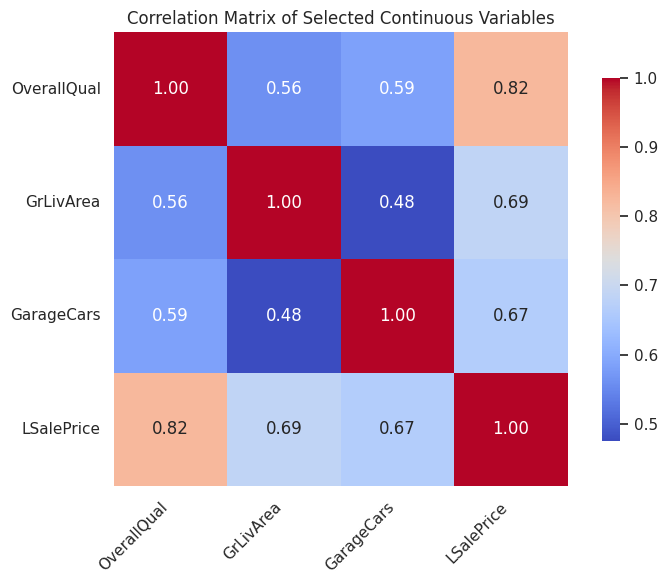

In [38]:
# Selected continuous variables correlation matrix
selected_continuous_data = train[top_continuous_vars + ['LSalePrice']]
# Compute the correlation matrix for selected continuous variables
selected_correlation_matrix = selected_continuous_data.corr()
# Set up the matplotlib figure
plt.figure(figsize=(8, 6))
# Create a heatmap of the selected correlation matrix
sns.heatmap(selected_correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
# Set title and labels
plt.title('Correlation Matrix of Selected Continuous Variables')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.2 Categorical Variables

Selection of categorical variables is also an important step in the feature selection process. Categorical variables are those that represent distinct categories or groups, such as 'HouseStyle', 'GarageType', and 'GarageFinish'. These variables can provide valuable information for our analysis, especially when combined with continuous variables.

In [39]:
# Categorical Variables
categorical_vars = data.select_dtypes(include=['object']).columns.tolist()

# Display the categorical variables
print(f"Categorical variables in the dataset: {categorical_vars}")


Categorical variables in the dataset: ['HouseStyle', 'ExterQual', 'ExterCond', 'KitchenQual', 'GarageType', 'GarageFinish', 'SaleType', 'SaleCondition']


In [40]:
from scipy.stats import f_oneway
import pandas as pd

# Dictionary to store both F-statistic and p-value
anova_results = {}

for col in categorical_vars:
    # Group the log sale price by category
    groups = [group['LSalePrice'] for _, group in train.groupby(col)]

    # Only run ANOVA if we have at least 2 groups
    if len(groups) > 1:
        f_stat, p_val = f_oneway(*groups)
        anova_results[col] = {'F-statistic': f_stat, 'p-value': p_val}

# Convert to DataFrame and sort by F-statistic
anova_df = pd.DataFrame(anova_results).T.sort_values(by='F-statistic', ascending=False)

# Show result
print(anova_df.round(3))

               F-statistic  p-value
ExterQual          678.488      0.0
KitchenQual        474.651      0.0
GarageFinish       446.768      0.0
GarageType         187.323      0.0
SaleCondition       80.705      0.0
SaleType            43.485      0.0
ExterCond           33.856      0.0
HouseStyle          31.192      0.0


**Why do we use ANOVA to test the significance of categorical variables?**
ANOVA (Analysis of Variance) is used to test the significance of categorical variables because it allows us to compare the means of a continuous response variable across different groups defined by categorical variables. Specifically, ANOVA helps us determine whether there are statistically significant differences in the means of the response variable (in this case, log sale price) among the different categories of the categorical variable.
If the p-value from ANOVA is less than a specified significance level (commonly 0.05), it indicates that at least one group mean is significantly different from the others. This suggests that the categorical variable has a significant effect on the response variable.

However, traditional ANOVA assumes that the variances of the groups are equal (homogeneity of variance). If this assumption is violated, it can lead to biased results. In such cases, Welch's ANOVA is a more robust alternative that does not assume equal variances.

Example of ANOVA results for the categorical variable `'ExterQual'`:

| ExterQual | Count | Mean (LogSalePrice) | Std Dev | Variances (Std^2) |
| --------- |-------| ------------------- | ------- |-------------------|
| TA        | 1788  | 11.832              | 0.296   | 0.087616          |
| Gd        | 986   | 12.307              | 0.291   | 0.084681          |
| Ex        | 107   | 12.802              | 0.292   | 0.085264          |
| Fa        | 35    | 11.306              | 0.495   | 0.245025          |

Note: The Fa group has a much higher variance (0.245025), likely due to its small sample size (35), which could contribute to bias in the ANOVA F-statistic.




In [41]:
# EXAMINE THE DISTRIBUTION OF CATEGORICAL VARIABLES (e.g., ExterQual)

# Step 1: Check the distribution of ExterQual (group sizes)
exterqual_counts = data['ExterQual'].value_counts()

exterqual_counts

from scipy.stats import f_oneway

# Step 2: Group LogSalePrice by each ExterQual level
grouped_data = [data[data['ExterQual'] == level]['LSalePrice'] for level in data['ExterQual'].unique()]

# Step 3: Perform traditional ANOVA
f_stat, p_val = f_oneway(*grouped_data)

# Step 4: Calculate mean and std for each group to check variance
group_stats = data.groupby('ExterQual')['LSalePrice'].agg(['count', 'mean', 'std']).sort_values(by='count', ascending=False)

f_stat, p_val, group_stats.round(3)

# Step 5: Check the variance of each group
# group_variances = data.groupby('ExterQual')['LSalePrice'].var().sort_values(ascending=False)
# group_variances.round(3)


(np.float64(857.7457093770604),
 np.float64(0.0),
            count    mean    std
 ExterQual                      
 TA          1788  11.832  0.296
 Gd           986  12.307  0.291
 Ex           107  12.802  0.292
 Fa            35  11.306  0.495)

#### Welch's ANOVA

**Why we should use Welch's ANOVA instead of the regular ANOVA?**
Welch's ANOVA is a robust alternative to the regular ANOVA when the assumption of homogeneity of variances (equal variances across groups) is violated. In many real-world datasets, the variances of different groups may not be equal, which can lead to inaccurate results when using regular ANOVA. Welch's ANOVA does not assume equal variances and is more reliable in such cases. It adjusts the **degrees of freedom based on the variances of each group**, making it a more appropriate choice when dealing with heterogeneous variances.

In regular ANOVA, degrees of freedom are calculated straightforwardly from sample sizes. But when group variances differ, Welch's ANOVA uses the **Welch-Satterthwaite equation** to compute adjusted (usually smaller, non-integer) degrees of freedom that account for the unequal variances. This adjustment makes the resulting F-test more accurate by being more conservative, reducing the chance of a false positive when variances are unequal.

The Welch-Satterthwaite equation is the formula used to calculate the adjusted degrees of freedom in Welch's ANOVA (and Welch's t-test). It looks like this:

$$df = \frac{\left(\sum_{i=1}^{k} \frac{s_i^2}{n_i}\right)^2}{\sum_{i=1}^{k} \frac{\left(\frac{s_i^2}{n_i}\right)^2}{n_i - 1}}$$
Where:

- $s_i^2$ = sample variance of group $i$
- $n_i$ = sample size of group $i$
- $k$ = number of groups

**Intuitively, what is it doing?**

It is essentially a weighted approximation. When group variances are unequal, you can't just pool all the information together as if the groups were equivalent. The equation produces a single "effective" degrees of freedom value that reflects how much reliable information you actually have, taking into account that some groups have larger, noisier variances than others.
Groups with large variances contribute less reliable information, so the equation down-weights them. The result is a degrees of freedom value that is typically smaller than what regular ANOVA would give you, which makes the critical value for your F-test larger and the test more conservative - reducing false positives when variances are heterogeneous.

In [21]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.8/204.8 kB 10.4 MB/s eta 0:00:00


[Documentation of pingouin.welch_anova](https://pingouin-stats.org/generated/pingouin.welch_anova.html)

In [44]:
import pingouin as pg

# Perform Welch's ANOVA on the original training set only
welch_results = []
for col in categorical_vars:
    if train[col].nunique() > 1:
        res = pg.welch_anova(dv='LSalePrice', between=col, data=train)
        res['Variable'] = col
        welch_results.append(res)

# Combine and sort results
welch_anova_df = pd.concat(welch_results, ignore_index=True).sort_values(by='F', ascending=False)

# Identify p-value column name (different version of pingouin has different names)
p_col = next((c for c in ['p-unc', 'p-val', 'pval'] if c in welch_anova_df.columns), welch_anova_df.columns[4])

print("Top Categorical Variables by F-statistic:")
display(welch_anova_df[['Variable', 'F', p_col]].round(3).head(5))

Top Categorical Variables by F-statistic:


,Variable,F,p_unc
1,ExterQual,630.538,0.0
5,GarageFinish,419.440,0.0
3,KitchenQual,399.507,0.0
4,GarageType,198.642,0.0
7,SaleCondition,85.051,0.0


#### **Other Mitigation Strategies:**

- **Merge Small Groups:** Combine small smaple group with another group or label it as “Other” and recalculate the F-statistic.
- **Penalty for Small Groups:** Adjust the F-statistic by scaling it with a penalty term, like $ \min(n_i) / \max(n_i) = 35 / 1791 \approx 0.0195 $, reducing its weight: $ F_{\text{adjusted}} = 858.62 \cdot 0.0195 \approx 16.74 $, though this is a crude adjustment.
- **Kruskal-Wallis Test:** Use a non-parametric test to avoid assumptions about variance.
- ...

In [48]:
# Selecting top categorical variables based on Welch's ANOVA results
cat_n = 3  # Number of top variables to select
top_categorical_vars = welch_anova_df['Variable'].head(cat_n).tolist()
print(f"Top {cat_n} categorical variables with highest F-statistic: {top_categorical_vars}")

Top 3 categorical variables with highest F-statistic: ['ExterQual', 'GarageFinish', 'KitchenQual']


In [49]:
# Selected features (continuous and categorical)
selected_features = top_continuous_vars + top_categorical_vars
print(f"Selected features for the model: {selected_features}")


Selected features for the model: ['OverallQual', 'GrLivArea', 'GarageCars', 'ExterQual', 'GarageFinish', 'KitchenQual']


## 4. Data Preprocessing

### 4.1 One-Hot Encoding

**What is One-Hot Encoding?**
In one-hot encoding, each unique category of the categorical variable is transformed into multiple binary (0/1) variables. Each binary variable represents a distinct category of the original variable. The number of binary variables created is equal to the number of unique categories in the original variable.

The code snippet below illustrates the process of applying one-hot encoding.

In [50]:
# Number of unique categories in each categorical variable
unique_categories = data[top_categorical_vars].nunique()
unique_categories
print(f"We have {sum(unique_categories)} unique categories across the selected categorical variables: \n{unique_categories}")

We have 13 unique categories across the selected categorical variables: 
ExterQual       4
GarageFinish    4
KitchenQual     5
dtype: int64


In [51]:
# OHC on the selected categorical variables
data_encoded = pd.get_dummies(data[selected_features], columns=top_categorical_vars, drop_first=True) # drop_first=True means we drop the first category to avoid multicollinearity

# Get the names of the newly created binary variables
encoded_variable_names = data_encoded.columns.difference(data.columns).tolist()

# Display the names of the newly created binary variables
print(f"{len(encoded_variable_names)} newly created binary variables after one-hot encoding: {encoded_variable_names}")


10 newly created binary variables after one-hot encoding: ['ExterQual_Fa', 'ExterQual_Gd', 'ExterQual_TA', 'GarageFinish_None', 'GarageFinish_RFn', 'GarageFinish_Unf', 'KitchenQual_Fa', 'KitchenQual_Gd', 'KitchenQual_Po', 'KitchenQual_TA']


In [52]:
# Display the first few rows of the encoded data
data_encoded.head()

,OverallQual,GrLivArea,GarageCars,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_Po,KitchenQual_TA
0,5,1629,2.0,False,False,True,False,False,False,False,False,False,True
1,6,1604,2.0,False,False,True,False,False,False,False,True,False,False
2,8,1338,2.0,False,True,False,False,False,False,False,True,False,False
3,8,1280,2.0,False,True,False,False,True,False,False,True,False,False
4,8,1616,2.0,False,True,False,False,True,False,False,True,False,False


- Did you notice the change in the variable names after one-hot encoding?
- The number of binary columns created is equal is less than the number of unique categories in the original variable? Why is that so?

### 4.2 Split Encoded Data Using Train/Test Index

To ensure the encoded data is the same data set we utilised before in data selection, we reuse the train/test index.


In [53]:
# Add target variable to the training and validation sets
data_encoded['SalePrice'] = data['SalePrice']
data_encoded['LSalePrice'] = data['LSalePrice']

# Generate training and validation sets
train = data_encoded.loc[index_train, :].copy()
valid = data_encoded.loc[index_valid, :].copy()

In [54]:
train.head()

,OverallQual,GrLivArea,GarageCars,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_Po,KitchenQual_TA,SalePrice,LSalePrice
721,6,952,1.0,False,False,True,False,False,True,True,False,False,False,121000,11.703546
2529,6,1993,2.0,False,False,True,False,True,False,False,False,False,True,190000,12.154779
2179,4,1346,1.0,False,False,True,False,False,True,False,False,False,True,112000,11.626254
103,7,1714,2.0,False,False,True,False,False,True,False,False,False,True,196500,12.188418
2796,6,1700,2.0,False,True,False,False,True,False,False,True,False,False,200000,12.206073


### 4.3 Feature Scaling
Feature scaling is a crucial step in data preprocessing, especially when dealing with continuous variables. It ensures that all features contribute equally to the model's performance by bringing them to a similar scale. In this case, we will apply standardization to the continuous variables.

Standard Scaling
Standard scaling is a data preprocessing technique used to transform features so that they have a mean of 0 and a standard deviation of 1.
It is often applied before training machine learning models that are sensitive to feature scale, such as linear regression, logistic regression, or methods using distance metrics (e.g., k-NN, SVM).


**The formula for Standard Scaling is:**
$$
z = \frac{x - \mu}{\sigma}
$$

Where:
- $x$: the original feature value

- $\mu$: the mean of the feature

- $\sigma$: the standard deviation of the feature

- $z$: the scaled (standardized) value



In [55]:
# Standardize the continuous variables in the training set
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and validation sets
train[top_continuous_vars] = scaler.fit_transform(train[top_continuous_vars])
valid[top_continuous_vars] = scaler.transform(valid[top_continuous_vars])

# Display the first few rows of the scaled training set
train.head()


,OverallQual,GrLivArea,GarageCars,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_Po,KitchenQual_TA,SalePrice,LSalePrice
721,-0.066418,-1.078892,-1.019583,False,False,True,False,False,True,True,False,False,False,121000,11.703546
2529,-0.066418,0.966366,0.298415,False,False,True,False,True,False,False,False,False,True,190000,12.154779
2179,-1.487409,-0.304798,-1.019583,False,False,True,False,False,True,False,False,False,True,112000,11.626254
103,0.644077,0.418214,0.298415,False,False,True,False,False,True,False,False,False,True,196500,12.188418
2796,-0.066418,0.390708,0.298415,False,True,False,False,True,False,False,True,False,False,200000,12.206073


## 5. Model


With Scikit-learn, we can easily train various staistical models. Below are the steps:


1.   Import the desired learning algorithm
2.   Define the model
3.   Variable selection
4.   Model selection


### 5.1 Training the Model

In [56]:
# Define target and predictors
response = 'LSalePrice'
predictors = top_continuous_vars + encoded_variable_names

# Prepare training and validation sets (ensure all predictors are float)
X_train = train[predictors].astype(float)
y_train = train[response]

X_valid = valid[predictors].astype(float)
y_valid = valid[response]


In [57]:
X_train.head()

,OverallQual,GrLivArea,GarageCars,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_Po,KitchenQual_TA
721,-0.066418,-1.078892,-1.019583,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2529,-0.066418,0.966366,0.298415,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2179,-1.487409,-0.304798,-1.019583,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
103,0.644077,0.418214,0.298415,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2796,-0.066418,0.390708,0.298415,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [58]:
import statsmodels.api as sm

# Add a constant column and fit the linear regression model
X_train_with_const = sm.add_constant(X_train)  # Add a constant column

# Fit the OLS model using statsmodels (OLS stands for Ordinary Least Squares)
ols = sm.OLS(y_train, X_train_with_const)
ols_results = ols.fit()

# Print the model summary with original variable names
print(ols_results.summary(xname=['Constant'] + predictors))

                            OLS Regression Results                            
Dep. Variable:             LSalePrice   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                     733.7
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               0.00
Time:                        08:44:15   Log-Likelihood:                 698.30
No. Observations:                2332   AIC:                            -1369.
Df Residuals:                    2318   BIC:                            -1288.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Constant             12.2523      0.02

Based on the above output, let's analyze the statistical significance of the variables and interpret the variable estimates.

To determine the statistically significant variables, we need to examine the p-values associated with each variable estimate.

By considering the variable estimates, we can interpret the magnitude and direction of the relationship between each predictor variable and the target variable. The variable estimates represent the estimated effect or impact of a one-unit change in the corresponding predictor variable on the target variable, while holding other variables constant.

To interpret the variable estimates, we can consider the sign of the estimate (positive or negative) and its magnitude. A positive estimate indicates a positive relationship between the predictor variable and the target variable, meaning that an increase in the predictor variable is associated with an increase in the target variable. Conversely, a negative estimate indicates an inverse relationship.

The magnitude of the estimate indicates the strength of the relationship. A larger magnitude suggests a more substantial effect, while a smaller magnitude implies a relatively weaker effect. It's essential to interpret the estimates in the context of the specific variables and the problem domain.

### 5.2 Making Predictions on the Validation Dataset

To make predictions, the process is straightforward. The following code demonstrates how to accomplish it:

In [ ]:
# Make predictions on the validation dataset
X_valid_with_const = sm.add_constant(X_valid)  # Add a constant column to the validation dataset
y_pred = ols_results.predict(X_valid_with_const)

### 5.3. Residual Diagnostics

The residuals represent the difference between the actual target variable values and the predicted values. By analyzing the residuals, we can evaluate the model's performance and identify potential issues.

In [ ]:
# Compute residuals
residuals = y_valid - y_pred

In [ ]:
#0. Residual Stat
residuals_series = pd.Series(residuals)

# Use describe() function
residuals_series.describe()

,0
count,584.000000
mean,-0.015057
std,0.172649
min,-0.728723
25%,-0.110417
50%,-0.012181
75%,0.101280
max,0.571642


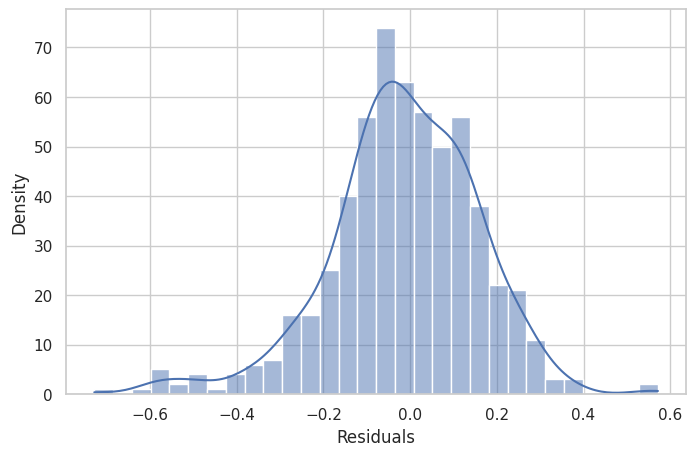

In [ ]:
#1. Residual Histogram
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Residual Histogram
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.show()

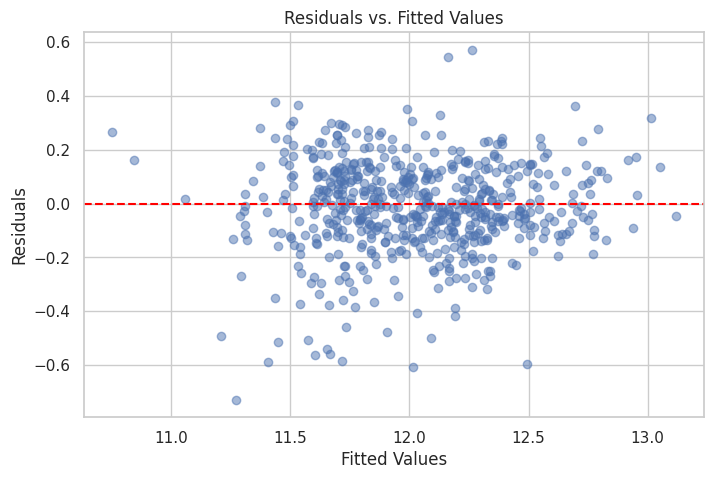

In [ ]:
# 2. Residuals vs. Fitted Values
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Residuals vs. Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

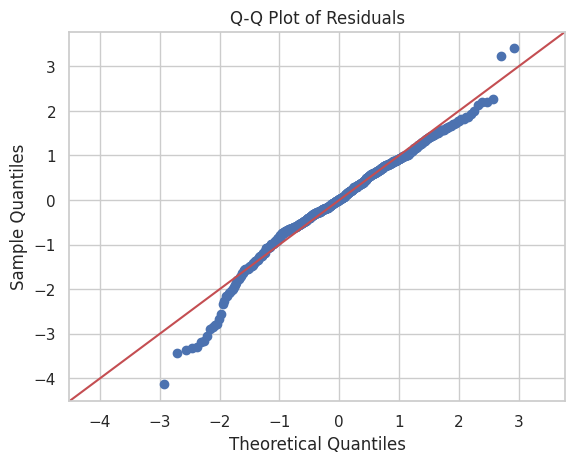

In [ ]:
# 3. Q-Q Plot
sm.qqplot(residuals, line="45", fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

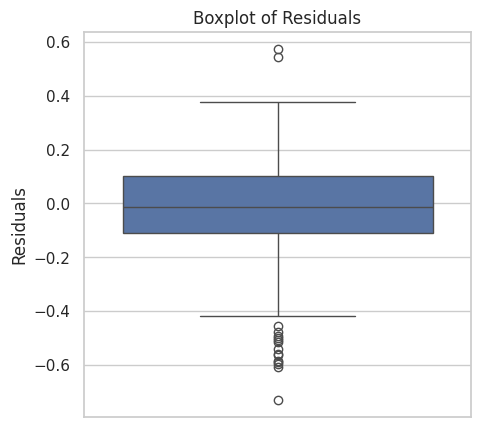

In [ ]:
# 4. Residuals Boxplot
plt.figure(figsize=(5, 5))
sns.boxplot(y=residuals)
plt.title("Boxplot of Residuals")
plt.ylabel("Residuals")
plt.show()

### 5.4 Model Evaluation Metrics

To evaluate the model's performance, we can use various metrics (such as MSE, RMSE, MAE, R2). These metrics provide insights into the model's predictive accuracy and the proportion of variance explained by the model.

- Mean Squared Error (MSE): The MSE measures the average squared difference between the actual and predicted values. A lower MSE indicates better model performance.
- Root Mean Squared Error (RMSE): The RMSE is the square root of the MSE. It provides a more interpretable measure of the model's predictive accuracy.
- Mean Absolute Error (MAE): The MAE measures the average absolute difference between the actual and predicted values. It is less sensitive to outliers than the MSE.
- R-squared (R2): The R-squared value represents the proportion of variance explained by the model. It ranges from 0 to 1, with higher values indicating a better fit.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Mean Squared Error (MSE)
mse = mean_squared_error(y_valid, y_pred)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Mean Absolute Error (MAE)
mae = np.mean(np.abs(residuals))

# R-squared
r2 = r2_score(y_valid, y_pred)

print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R-squared: {r2:.3f}")


MSE: 0.030
RMSE: 0.173
MAE: 0.132
R-squared: 0.827


In [ ]:
# Compare the model's performance on training and validation sets
y_train_pred = ols_results.predict(sm.add_constant(X_train))
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = np.mean(np.abs(y_train - y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)
print(f"Training MSE: {train_mse:.3f}")
print(f"Training RMSE: {train_rmse:.3f}")
print(f"Training MAE: {train_mae:.3f}")
print(f"Training R-squared: {train_r2:.3f}")


Training MSE: 0.032
Training RMSE: 0.179
Training MAE: 0.126
Training R-squared: 0.804


Comparing the model's performance on the training and validation sets is crucial to assess whether the model is overfitting or underfitting. If the training metrics are significantly better than the validation metrics, it may indicate overfitting, where the model learns noise in the training data rather than generalizing well to unseen data. Conversely, if both sets have similar performance, it suggests that the model is generalizing well.

What do you think about the model's performance on the training and validation sets? Is it overfitting or underfitting? What would you do to improve the model's performance?

## 6. Training the Model with Sckit-Learn Library

In [ ]:
from sklearn.linear_model import LinearRegression

# Define the model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the validation set
y_pred_sklearn = model.predict(X_valid)

In [ ]:
# Evaluate the model using Scikit-Learn metrics
mse_sklearn = mean_squared_error(y_valid, y_pred_sklearn)
rmse_sklearn = np.sqrt(mse_sklearn)
mae_sklearn = np.mean(np.abs(y_valid - y_pred_sklearn))
r2_sklearn = r2_score(y_valid, y_pred_sklearn)
print(f"Scikit-Learn MSE: {mse_sklearn:.3f}")
print(f"Scikit-Learn RMSE: {rmse_sklearn:.3f}")
print(f"Scikit-Learn MAE: {mae_sklearn:.3f}")
print(f"Scikit-Learn R-squared: {r2_sklearn:.3f}")


Scikit-Learn MSE: 0.030
Scikit-Learn RMSE: 0.173
Scikit-Learn MAE: 0.132
Scikit-Learn R-squared: 0.827


In [ ]:
# Check if coefficient from two models are approximately equal

np.allclose(ols_results.params[1:], model.coef_)

True

In [ ]:
# Confirm that two models have same coef
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "OLS Coefficients": ols_results.params[1:].values,
    "Sklearn Coefficients": model.coef_
})

coef_df

,Feature,OLS Coefficients,Sklearn Coefficients
0,OverallQual,0.160176,0.160176
1,GrLivArea,0.113841,0.113841
2,GarageCars,0.061578,0.061578
3,ExterQual_Fa,-0.287957,-0.287957
4,ExterQual_Gd,-0.052877,-0.052877
5,ExterQual_TA,-0.066254,-0.066254
6,GarageFinish_None,-0.145933,-0.145933
7,GarageFinish_RFn,-0.010734,-0.010734
8,GarageFinish_Unf,-0.097733,-0.097733
9,KitchenQual_Fa,-0.210086,-0.210086
